# GSM8k


In [43]:

import json
from math_verify import parse, verify, LatexExtractionConfig, ExprExtractionConfig

def compile_predictions(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            # Get model generation output (usually first item)
            llm_output = data['model_generation'][0] if isinstance(data['model_generation'], list) else data['model_generation']
            answer = parse(llm_output, extraction_config=extraction_target)
            
            result = verify(gold, answer)
            results.append(result)
    
    accuracy = sum(results) / len(results) if results else 0
    return accuracy

from math import comb
def pass_at_k(n, c, k):
    """
    n: 总样本数
    c: 通过的样本数
    k: 评估的候选数
    """
    if n < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

def compile_predictions_BoN_passK(predictions_file):
    extraction_target = (ExprExtractionConfig(), LatexExtractionConfig())
    results = []
    with open(predictions_file, 'r') as f:
        for line in f:
            data = json.loads(line)
            gold = parse(f"${data['answer']}$", extraction_config=extraction_target)
            
            o_results = []
            # Use all generations to verify
            for llm_output in data['model_generation']:
                answer = parse(llm_output, extraction_config=extraction_target)
                result = verify(gold, answer)
                o_results.append(result)
            results.append(o_results)
    
    # 计算BoN - 检查每个问题是否至少有一个正确
    BoN = sum(1 for o_result in results if any(o_result)) / len(results) if results else 0
    
    #  计算Pass@K - 统计所有通过的样本
    total_samples = sum(len(o_result) for o_result in results)
    correct_samples = sum(sum(o_result) for o_result in results)
    passK = pass_at_k(total_samples, correct_samples, 1)
    
    return BoN, passK


In [44]:
import matplotlib.pyplot as plt

def draw_comparison_fig(baseline_x, baseline_y, seal_x, seal_y, x_label, y_label, title):
    plt.figure(figsize=(10, 5))
    plt.plot(baseline_x, baseline_y, marker='o', linestyle='-', color='b', label='Baseline')
    plt.plot(seal_x, seal_y, marker='o', linestyle='-', color='r', label='SEAL')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.ylim(bottom=0, top=1)
    plt.legend()
    plt.show()

## Example

baseline_accuracy:  0.7740712661106899
seal_accuracy:  0.8051554207733131


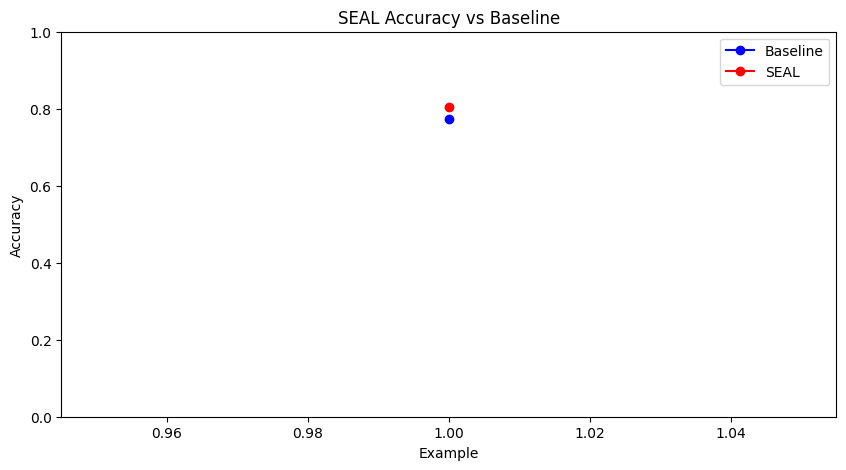

In [45]:

baseline_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/predictions.jsonl"
seal_path = "/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/1/predictions.jsonl"

baseline_accuracies = []
seal_accuracies = []
baseline_accuracy = compile_predictions(baseline_path)
seal_accuracy = compile_predictions(seal_path)
baseline_accuracies.append(baseline_accuracy)
seal_accuracies.append(seal_accuracy)
print("baseline_accuracy: ", baseline_accuracy)
print("seal_accuracy: ", seal_accuracy)
x = [1]
y = [baseline_accuracy, seal_accuracy]
x_label = "Example"
y_label = "Accuracy"
title = "SEAL Accuracy vs Baseline"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Temp

baseline_accuracy: 0.7717968157695224, seal_accuracy: 0.8059135708870356
baseline_accuracy: 0.824109173616376, seal_accuracy: 0.7945413191811979
baseline_accuracy: 0.778620166793025, seal_accuracy: 0.7778620166793025
baseline_accuracy: 0.4973464746019712, seal_accuracy: 0.3775587566338135


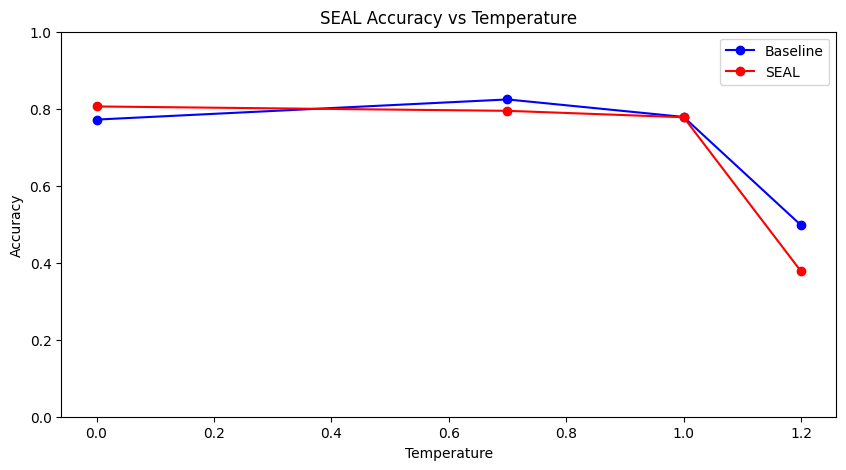

In [46]:
# temp = 0, 0.7, 1.0, 1.2
temps = [0, 0.7, 1.0, 1.2]
baseline_accuracies = []
seal_accuracies = []

for temp in temps:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/{temp}/16384/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/{temp}/16384/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")

x = temps
y = seal_accuracies
x_label = "Temperature"
y_label = "Accuracy"
title = "SEAL Accuracy vs Temperature"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Max Tokens

baseline_accuracy: 0.7740712661106899, seal_accuracy: 0.8051554207733131
baseline_accuracy: 0.7717968157695224, seal_accuracy: 0.8059135708870356
baseline_accuracy: 0.775587566338135, seal_accuracy: 0.8059135708870356


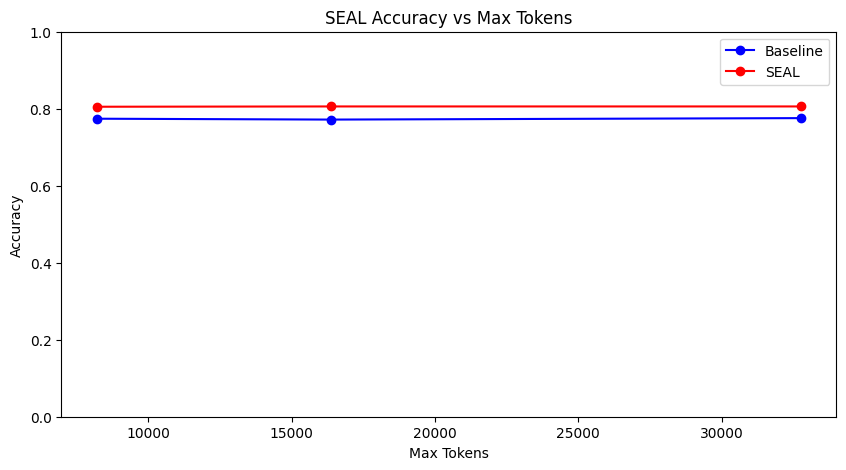

In [47]:
max_tokens = [8192, 16384, 32768]
baseline_accuracies = []
seal_accuracies = []
for max_token in max_tokens:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/{max_token}/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/{max_token}/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")
    
x = max_tokens
y = seal_accuracies
x_label = "Max Tokens"
y_label = "Accuracy"
title = "SEAL Accuracy vs Max Tokens"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

## Num of Samples  

In [ ]:
num_samples = [1, 8, 16]
baseline_accuracies = []
seal_accuracies = []
for num_sample in num_samples:
    baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/{num_sample}/0/8192/predictions.jsonl"
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/{num_sample}/0/8192/1/predictions.jsonl"

    baseline_accuracy = compile_predictions(baseline_path)
    seal_accuracy = compile_predictions(seal_path)
    baseline_accuracies.append(baseline_accuracy)
    seal_accuracies.append(seal_accuracy)
    print(f"baseline_accuracy: {baseline_accuracy}, seal_accuracy: {seal_accuracy}")

x = num_samples
y = seal_accuracies
x_label = "Num of Samples"
y_label = "Accuracy"
title = "SEAL Accuracy vs Num of Samples"
draw_comparison_fig(x, baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

baseline_accuracy: 0.7740712661106899, seal_accuracy: 0.8051554207733131


FileNotFoundError: [Errno 2] No such file or directory: '/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/8/0/8192/predictions.jsonl'

## Scale

baseline_accuracy: 0.7740712661106899
seal_accuracy: 0.8142532221379833
seal_accuracy: 0.8051554207733131
seal_accuracy: 0.8051554207733131


ValueError: x and y must have same first dimension, but have shapes (1,) and (3,)

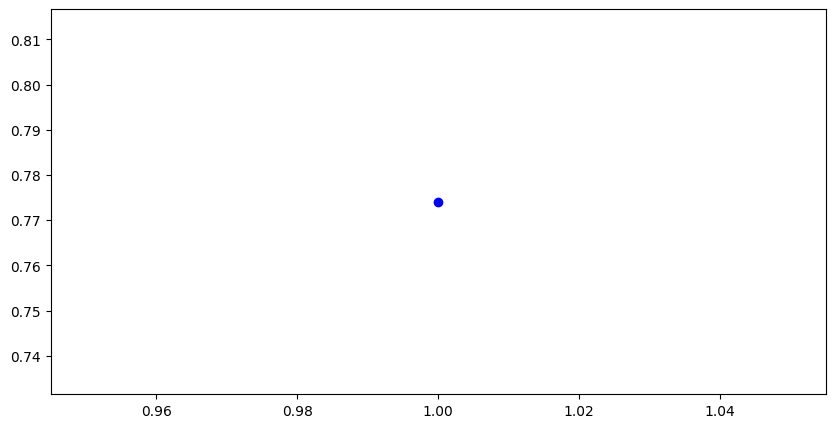

In [48]:
scale = [0.5, 1, 1.5]
baseline_accuracies = []
seal_accuracies = []
baseline_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-baseline/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/predictions.jsonl"
baseline_accuracy = compile_predictions(baseline_path)
baseline_accuracies.append(baseline_accuracy)
print(f"baseline_accuracy: {baseline_accuracy}")

for scale in scale:
    seal_path = f"/media/volume/llm/llm_steering_reasoning/results/deepseek-seal/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B/gsm8k_test/1/0/8192/{scale}/predictions.jsonl"
    seal_accuracy = compile_predictions(seal_path)
    seal_accuracies.append(seal_accuracy)
    print(f"seal_accuracy: {seal_accuracy}")
x = scale
y = seal_accuracies
x_label = "Scale"
y_label = "Accuracy"
title = "SEAL Accuracy vs Scale"
draw_comparison_fig([1], baseline_accuracies, x, seal_accuracies, x_label, y_label, title)

# MATH500